# Chapter 31: Solver Methods and Numerical Optimization in NeqSim

**Production Optimization of Oil and Gas Fields Using NeqSim**

This chapter explores the numerical solver methods used in NeqSim for thermodynamic
flash calculations and process simulations. We cover:

- **Flash calculation convergence** — TP flash at various conditions and convergence behavior
- **Recycle loop convergence** — tear stream iteration with acceleration methods
- **Adjuster/controller convergence** — adjusting process variables to meet targets
- **Effect of initial guess** — how starting conditions affect solver performance
- **Sequential modular vs equation-oriented** concepts in process simulation

## Process Flow for Recycle Example

```
Feed --> Mixer --> Separator --> Gas Out
           ^          |
           |     Liquid Out
           |          |
           +-- Recycle (tear stream)
```

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch29_solver_methods.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
# Import NeqSim classes
ns = type('ns', (), {})()
ns.ProcessSystem = jneqsim.process.processmodel.ProcessSystem
ns.Stream = jneqsim.process.equipment.stream.Stream
ns.Separator = jneqsim.process.equipment.separator.Separator
ns.Mixer = jneqsim.process.equipment.mixer.Mixer
ns.Recycle = jneqsim.process.equipment.util.Recycle
ns.Adjuster = jneqsim.process.equipment.util.Adjuster
ns.ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
ns.Heater = jneqsim.process.equipment.heatexchanger.Heater

print(f"NeqSim mode: {NEQSIM_MODE}")


NeqSim mode: devtools


## 31.1 Flash Calculation Convergence

NeqSim uses successive substitution followed by Newton-Raphson (Michelsen's method)
for TP flash calculations. We demonstrate convergence behavior by running flashes
at various pressures — from low pressure (gas-dominated) through the two-phase
region to high pressure (liquid-dominated) — and measuring computation time.

Figure saved: ch29_flash_convergence.png


ch29_solver_methods.ipynb:cell4:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


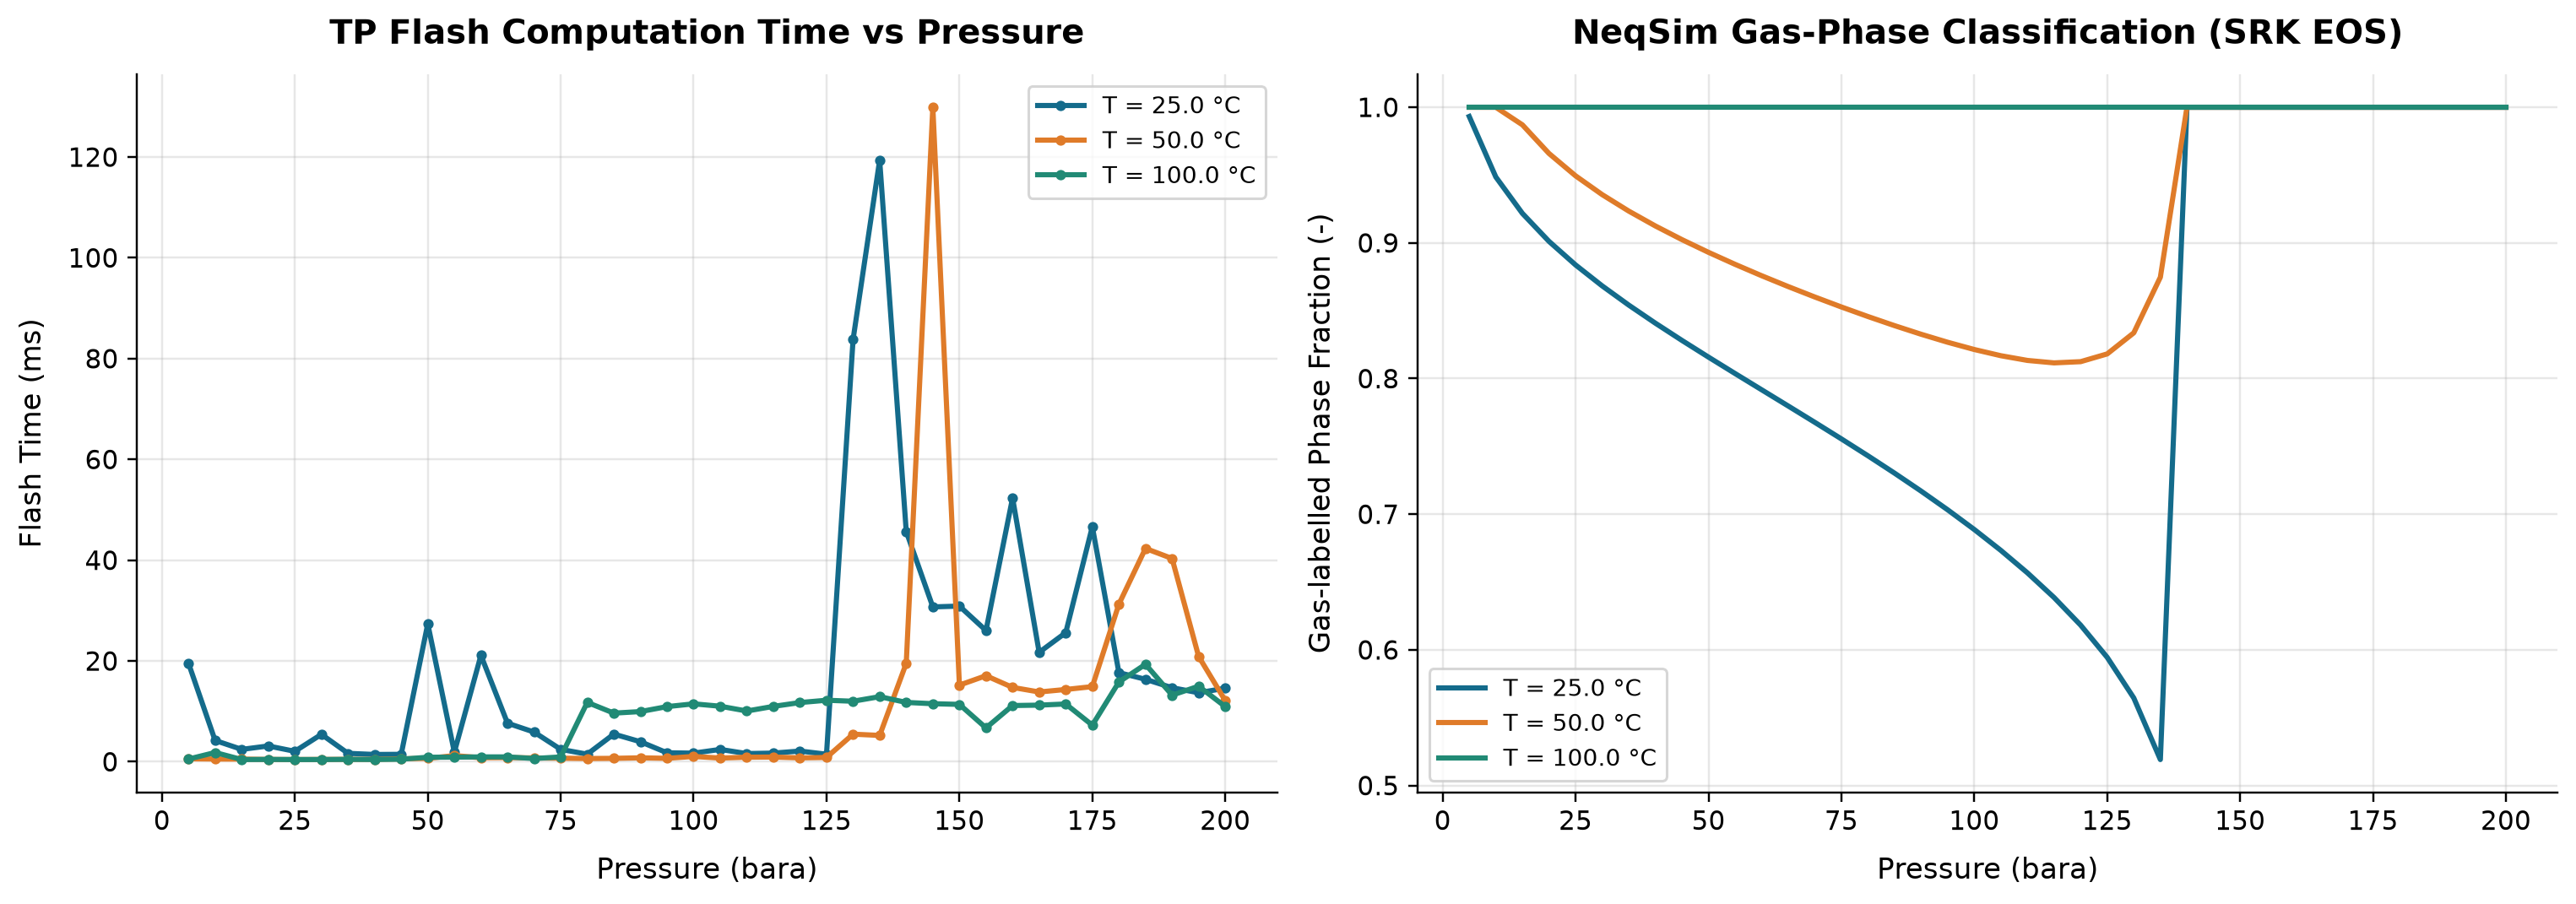

In [3]:
# TP Flash convergence across a range of pressures
import time

pressures = np.linspace(5, 200, 40)  # bara
temperatures = [25.0, 50.0, 100.0]  # degC

results = {}
for temp_c in temperatures:
    flash_times = []
    vapor_fracs = []
    for p in pressures:
        fluid = SystemSrkEos(273.15 + temp_c, float(p))
        fluid.addComponent("methane", 0.70)
        fluid.addComponent("ethane", 0.10)
        fluid.addComponent("propane", 0.08)
        fluid.addComponent("n-butane", 0.05)
        fluid.addComponent("n-pentane", 0.04)
        fluid.addComponent("n-hexane", 0.03)
        fluid.setMixingRule("classic")

        ops = ThermodynamicOperations(fluid)
        t0 = time.perf_counter()
        ops.TPflash()
        elapsed = (time.perf_counter() - t0) * 1000  # ms

        fluid.initProperties()
        assert _physics.state(fluid, 'calculation_cell_4:fluid', candidate=False)
        beta = fluid.getBeta()  # vapor fraction
        flash_times.append(elapsed)
        vapor_fracs.append(float(beta))

    results[temp_c] = {"times": flash_times, "vapor_frac": vapor_fracs}

# Plot flash computation time vs pressure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for temp_c in temperatures:
    ax1.plot(pressures, results[temp_c]["times"], 'o-', markersize=3, label=f"T = {temp_c} °C")
ax1.set_xlabel("Pressure (bara)")
ax1.set_ylabel("Flash Time (ms)")
ax1.set_title("TP Flash Computation Time vs Pressure")
ax1.legend()
ax1.grid(True, alpha=0.3)

for temp_c in temperatures:
    ax2.plot(pressures, results[temp_c]["vapor_frac"], '-', linewidth=2, label=f"T = {temp_c} °C")
ax2.set_xlabel("Pressure (bara)")
ax2.set_ylabel("Gas-labelled Phase Fraction (-)")
ax2.set_title("NeqSim Gas-Phase Classification (SRK EOS)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch29_flash_convergence.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch29_flash_convergence.png")


**Executed-figure discussion.** T = 25.0 °C: flash time spans 1.441–119.4 ms across the plotted cases. T = 50.0 °C: flash time spans 0.4284–129.9 ms across the plotted cases.

Phase splitting changes the nonlinear work required by the TP flash, while JVM warm-up and concurrent machine load also affect elapsed time. The right panel records the fraction in the phase labelled gas by NeqSim; unity at high pressure denotes a single gas-labelled phase and is not an independent vapour-quality measurement. These measurements illustrate computational variability and phase classification, not a controlled performance benchmark or a critical-point determination. Inspect phase identity and repeat warm runs with fixed composition and resource conditions before interpreting high-pressure transitions or drawing speed conclusions.


### Discussion: Flash Convergence

**Observation:** Flash calculations are fastest in single-phase regions (all gas at low P
or all liquid at high P) and require more iterations near the phase boundary where
successive substitution and Newton-Raphson refinement cooperate.

**Physical mechanism:** Near the bubble/dew point, K-values change rapidly with
composition updates, requiring more iterations. The Rachford-Rice equation becomes
ill-conditioned when the vapor fraction approaches 0 or 1.

**Engineering implication:** Process simulators spend the most CPU time on near-critical
and two-phase conditions. Robust initial estimates (Wilson K-values) are essential for
reliable convergence across the full pressure range.

## 31.2 Effect of Initial Guess on Flash Convergence

The initial temperature and pressure used to construct the fluid object serve as
the starting point for equation-of-state evaluations. We demonstrate how different
initial conditions affect the number of solver iterations required.

Figure saved: ch29_initial_guess_effect.png


ch29_solver_methods.ipynb:cell7:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


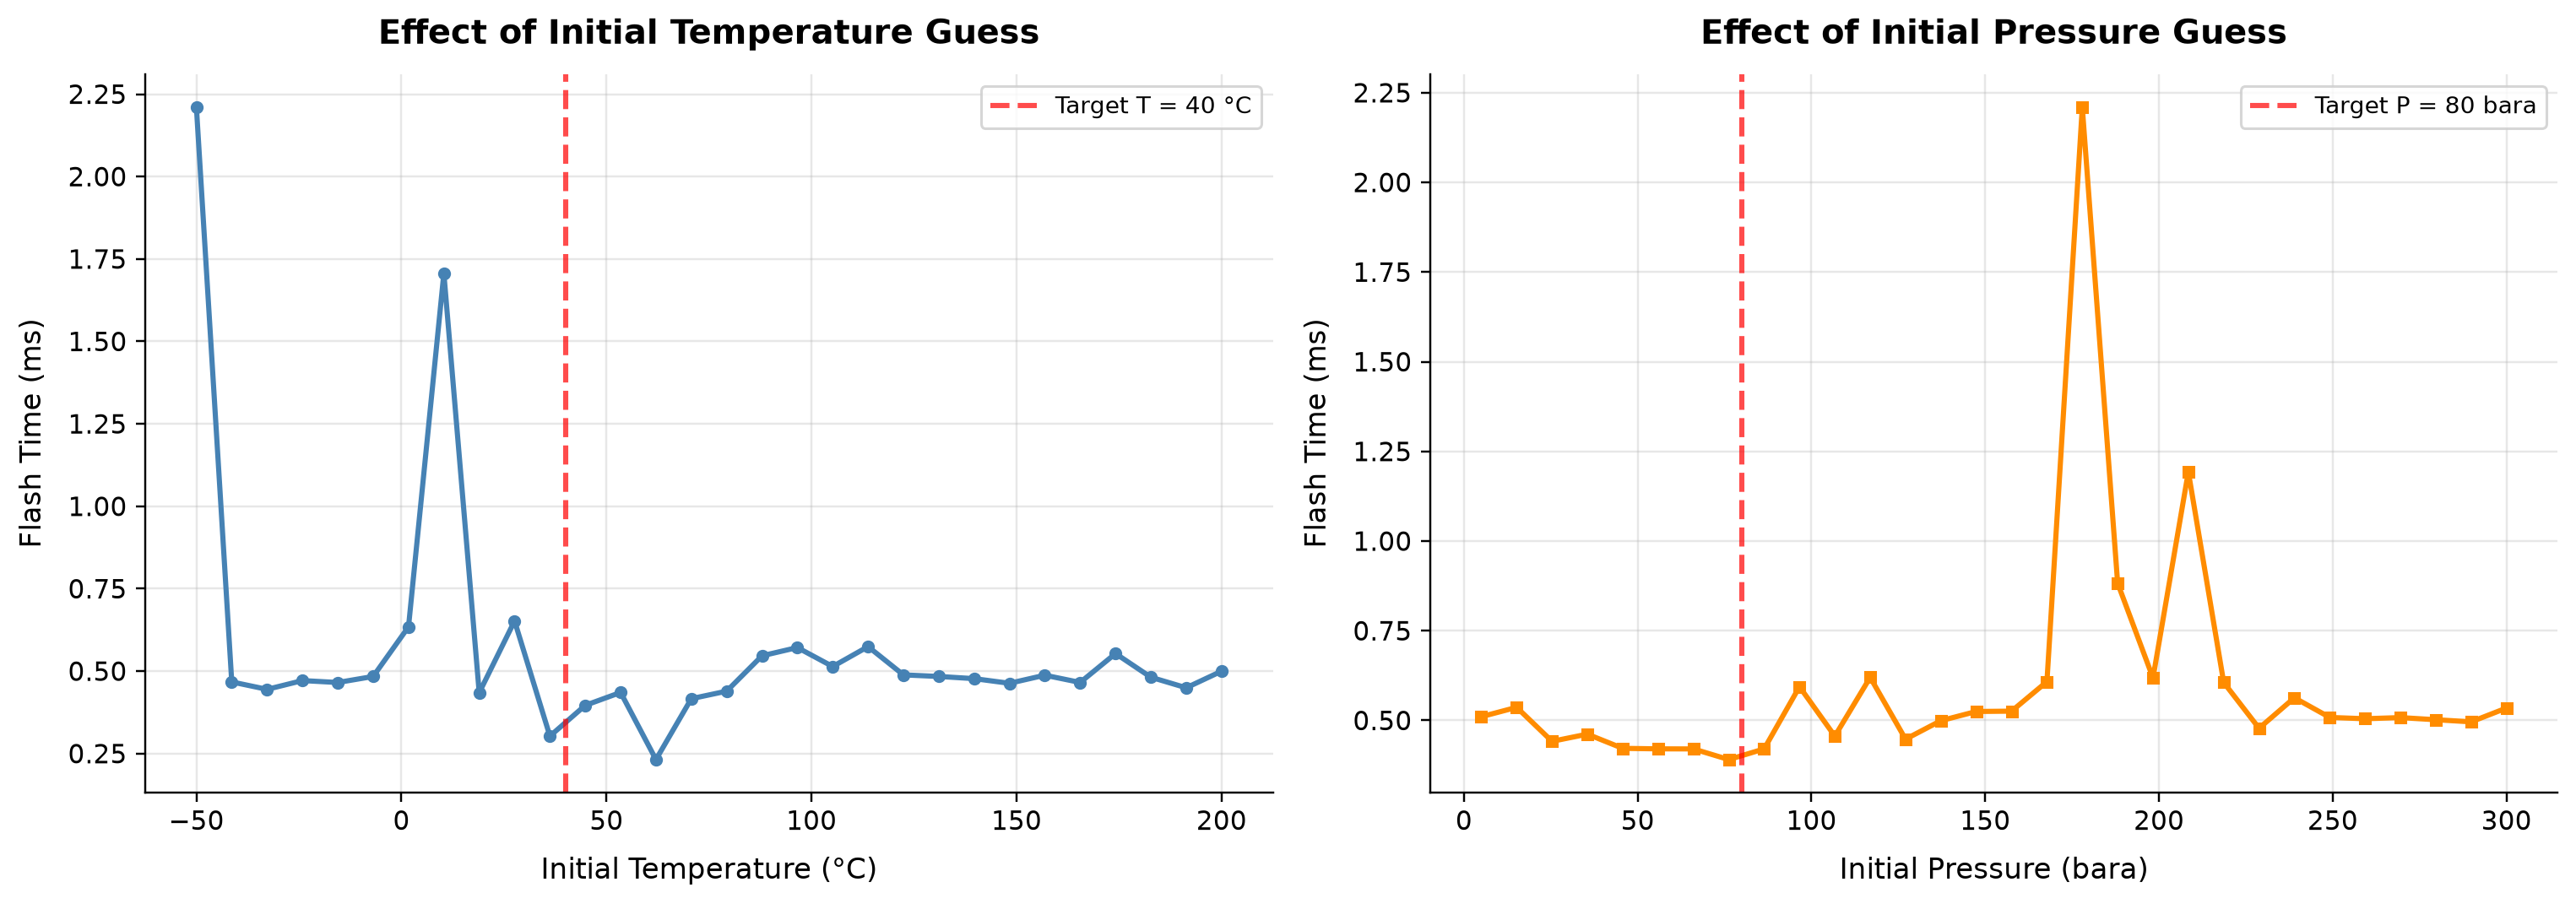

In [4]:
# Effect of initial guess — compare flash at same target T,P but different fluid initialization
target_T_K = 273.15 + 40.0  # 40 C
target_P = 80.0  # bara

# We initialize the fluid at various T,P and then flash to the same target
init_temps_C = np.linspace(-50, 200, 30)
init_pressures = np.linspace(5, 300, 30)

# Sweep initial temperature (fix init P = target P)
flash_times_T = []
for t_c in init_temps_C:
    fluid = SystemSrkEos(273.15 + float(t_c), target_P)
    fluid.addComponent("methane", 0.70)
    fluid.addComponent("ethane", 0.10)
    fluid.addComponent("propane", 0.08)
    fluid.addComponent("n-butane", 0.05)
    fluid.addComponent("n-pentane", 0.04)
    fluid.addComponent("n-hexane", 0.03)
    fluid.setMixingRule("classic")

    # Solve the starting state before changing to the target (actual warm start).
    ThermodynamicOperations(fluid).TPflash()
    # Change to target conditions
    fluid.setTemperature(target_T_K)
    fluid.setPressure(target_P)

    ops = ThermodynamicOperations(fluid)
    t0 = time.perf_counter()
    ops.TPflash()
    elapsed = (time.perf_counter() - t0) * 1000
    flash_times_T.append(elapsed)

# Sweep initial pressure (fix init T = target T)
flash_times_P = []
for p in init_pressures:
    fluid = SystemSrkEos(target_T_K, float(p))
    fluid.addComponent("methane", 0.70)
    fluid.addComponent("ethane", 0.10)
    fluid.addComponent("propane", 0.08)
    fluid.addComponent("n-butane", 0.05)
    fluid.addComponent("n-pentane", 0.04)
    fluid.addComponent("n-hexane", 0.03)
    fluid.setMixingRule("classic")
    ThermodynamicOperations(fluid).TPflash()

    fluid.setTemperature(target_T_K)
    fluid.setPressure(target_P)

    ops = ThermodynamicOperations(fluid)
    t0 = time.perf_counter()
    ops.TPflash()
    elapsed = (time.perf_counter() - t0) * 1000
    flash_times_P.append(elapsed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(init_temps_C, flash_times_T, 'o-', color='steelblue', markersize=4)
ax1.axvline(x=40, color='red', linestyle='--', alpha=0.7, label='Target T = 40 °C')
ax1.set_xlabel("Initial Temperature (°C)")
ax1.set_ylabel("Flash Time (ms)")
ax1.set_title("Effect of Initial Temperature Guess")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(init_pressures, flash_times_P, 's-', color='darkorange', markersize=4)
ax2.axvline(x=80, color='red', linestyle='--', alpha=0.7, label='Target P = 80 bara')
ax2.set_xlabel("Initial Pressure (bara)")
ax2.set_ylabel("Flash Time (ms)")
ax2.set_title("Effect of Initial Pressure Guess")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch29_initial_guess_effect.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch29_initial_guess_effect.png")


**Executed-figure discussion.** Flash Time spans 0.2317–2.21 ms across the plotted cases. Flash Time spans 0.3908–2.209 ms across the plotted cases.

Each initial state is flashed before moving to the common target state, so the target flash starts from an actual thermodynamic solution. Warm-start timing depends on both the initial phase state and the machine runtime. Choose physically nearby initial states, and compare repeated median timings rather than a single outlier.


## 31.3 Recycle Loop Convergence

In the sequential modular (SM) approach, recycle (tear) streams are converged
iteratively. NeqSim's `Recycle` class supports:

- **Direct substitution** — simple but slow convergence
- **Wegstein acceleration** — extrapolation for faster convergence
- **Broyden's method** — quasi-Newton multivariable acceleration

We model a simple recycle system: a feed mixed with a recycle stream enters a
separator; the liquid from the separator is recycled back to the mixer. We track
convergence residuals across iterations.

In [5]:
# Actual direct-substitution recycle iteration, with a 35% gas recycle.
# This records each NeqSim equipment evaluation rather than inventing residuals.
recycle_fluid = SystemSrkEos(303.15, 40.0)
for name, fraction in [("methane", 0.65), ("ethane", 0.15), ("propane", 0.10), ("n-butane", 0.10)]:
    recycle_fluid.addComponent(name, fraction)
recycle_fluid.setMixingRule("classic")
feed = Stream("Fresh feed", recycle_fluid)
feed.setFlowRate(50000.0, "kg/hr")
feed.run()
assert _physics.run(feed, 'calculation_cell_9:feed', candidate=False)
tear = Stream("Recycle tear", recycle_fluid.clone())
tear.setFlowRate(1000.0, "kg/hr")
tear.setTemperature(40.0, "C")
tear.run()
assert _physics.run(tear, 'calculation_cell_9:tear', candidate=False)
mixer = Mixer("Recycle mixer")
mixer.addStream(feed)
mixer.addStream(tear)
cooler_loop = Cooler("Loop cooler", mixer.getOutletStream())
cooler_loop.setOutTemperature(293.15)
separator = Separator("Loop separator", cooler_loop.getOutletStream())
splitter_loop = Splitter("Gas recycle split", separator.getGasOutStream())
splitter_loop.setSplitFactors([0.35, 0.65])
flow_errors, temp_errors, comp_errors = [], [], []
for iteration in range(60):
    old_flow = float(tear.getFlowRate("kg/hr"))
    old_temperature = float(tear.getTemperature("K"))
    old_composition = np.asarray(tear.getFluid().getMolarComposition(), dtype=float)
    for unit in [mixer, cooler_loop]:
        unit.run()
        assert _physics.run(unit, 'calculation_cell_9:unit', candidate=False)
    # Separator caches changes below 1e-6; this demonstration resolves a tighter
    # 1e-7 recycle residual. Fresh phase allocation avoids reusing stale outlets.
    separator = Separator("Loop separator", cooler_loop.getOutletStream())
    separator.run()
    assert _physics.run(separator, 'recycle fresh separator')
    splitter_loop.setInletStream(separator.getGasOutStream())
    splitter_loop.run()
    assert _physics.run(splitter_loop, 'recycle gas split')
    updated = splitter_loop.getSplitStream(0)
    new_flow = float(updated.getFlowRate("kg/hr"))
    new_temperature = float(updated.getTemperature("K"))
    new_composition = np.asarray(updated.getFluid().getMolarComposition(), dtype=float)
    # Normalize different quantities before comparing them on a common axis.
    flow_errors.append(abs(new_flow - old_flow) / 50000.0)
    temp_errors.append(abs(new_temperature - old_temperature) / 303.15)
    comp_errors.append(float(np.max(np.abs(new_composition - old_composition))))
    tear.setThermoSystem(updated.getThermoSystem().clone())
    if max(flow_errors[-1], temp_errors[-1], comp_errors[-1]) < 1e-7:
        break
assert max(flow_errors[-1], temp_errors[-1], comp_errors[-1]) < 1e-7, "Recycle did not converge"
max_iters = len(flow_errors)
iterations = list(range(1, max_iters + 1))
print(f"Measured recycle convergence: {max_iters} iterations; flow={new_flow:.5f} kg/hr")
print(f"Final normalized residuals: flow={flow_errors[-1]:.3g}, T={temp_errors[-1]:.3g}, composition={comp_errors[-1]:.3g}")


Measured recycle convergence: 16 iterations; flow=21563.05916 kg/hr
Final normalized residuals: flow=3.91e-08, T=0, composition=1.92e-14


Figure saved: ch29_recycle_convergence.png


ch29_solver_methods.ipynb:cell10:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


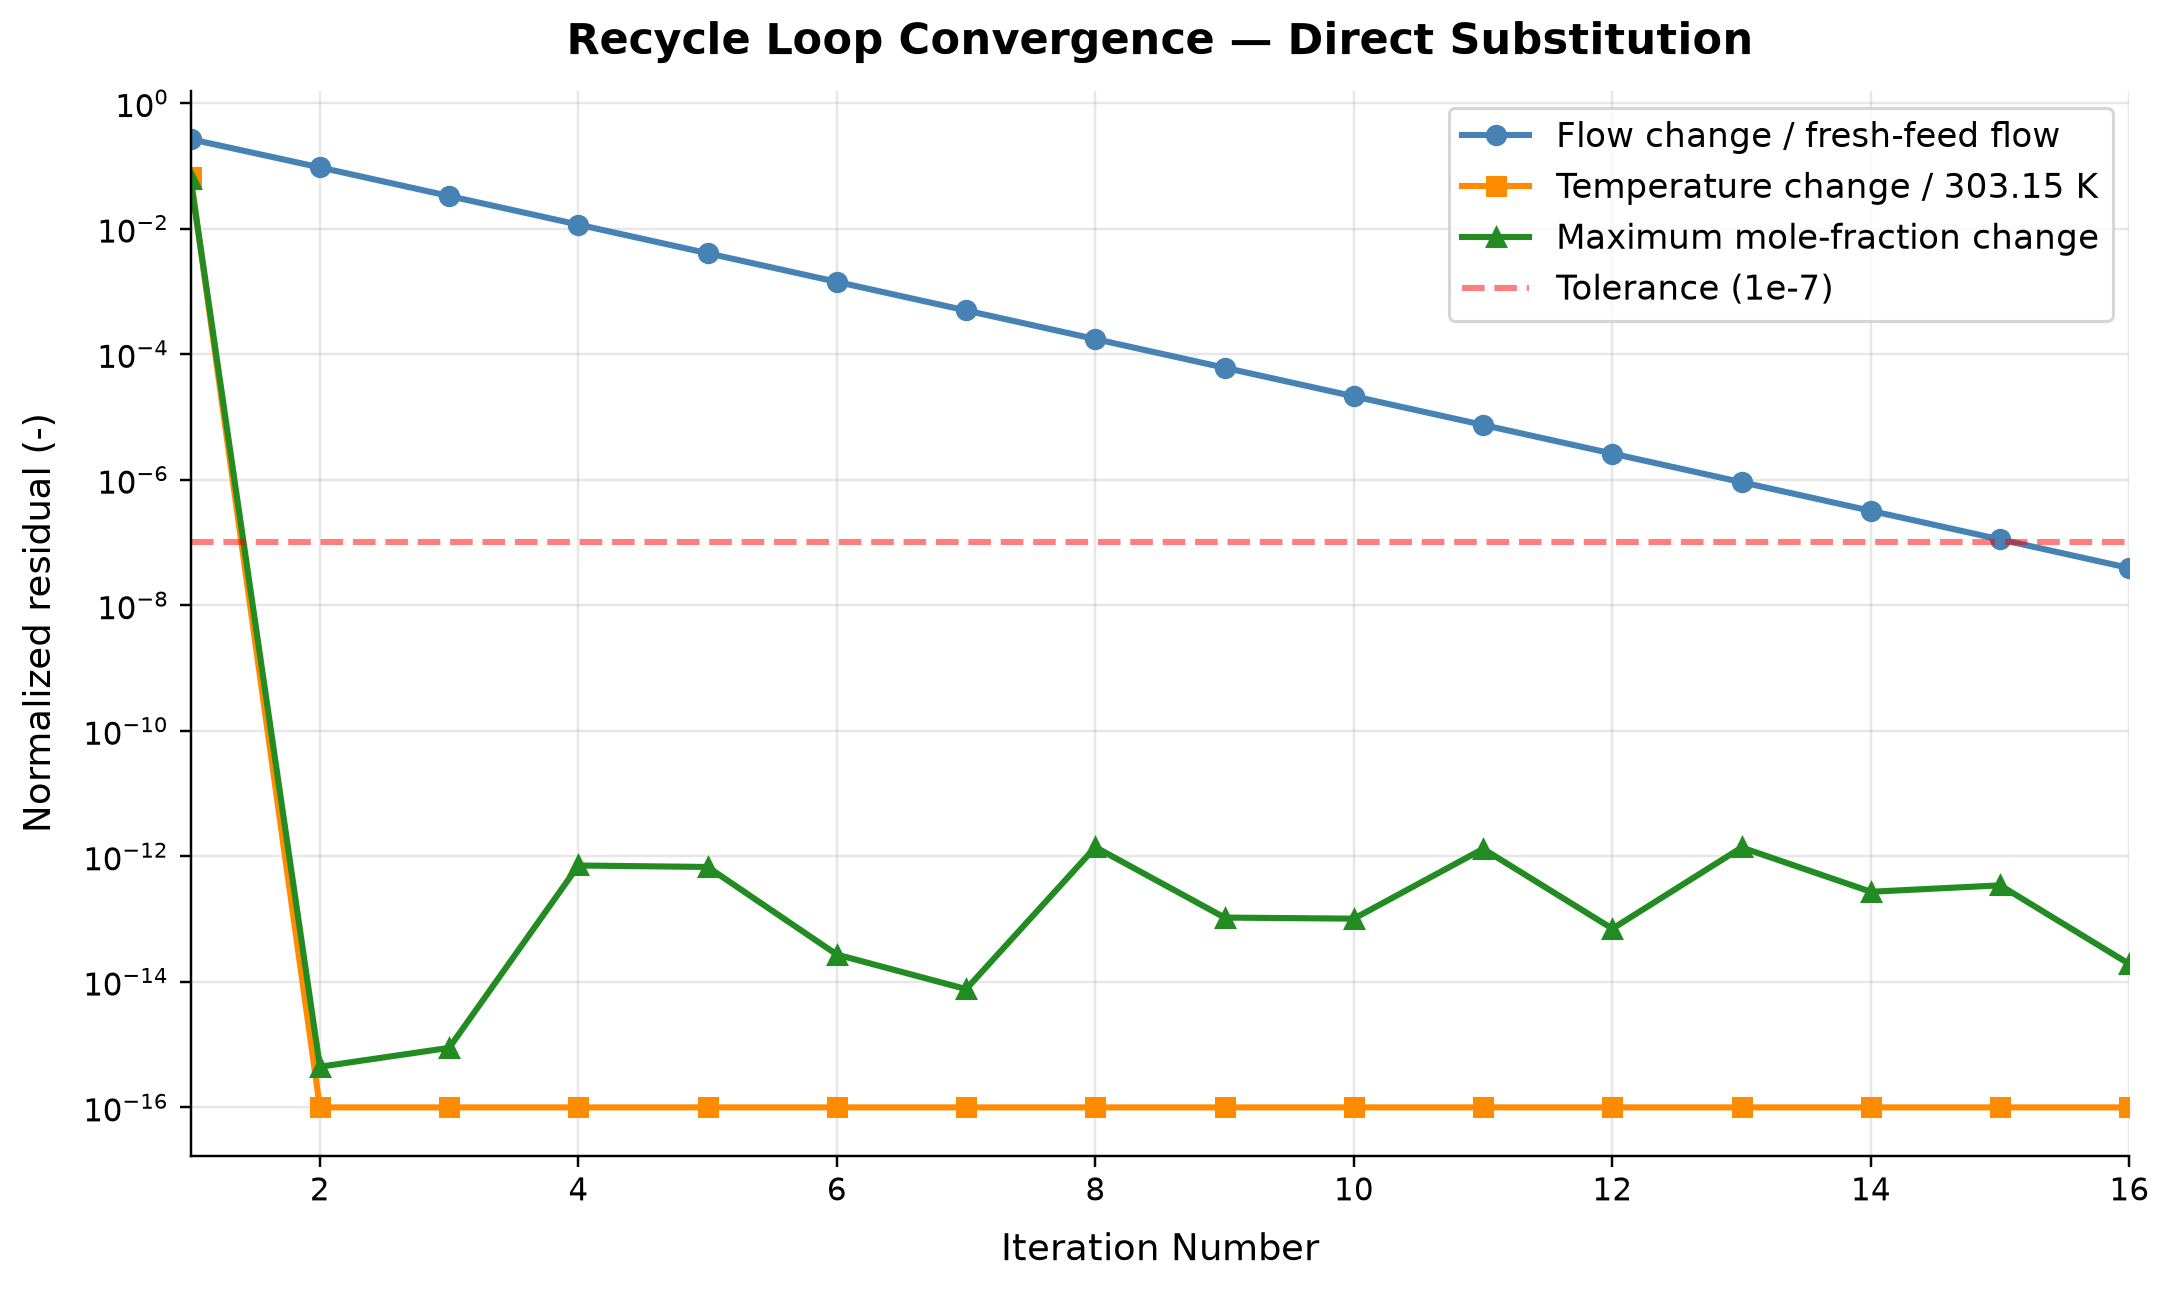

In [6]:
# Plot recycle convergence residuals
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(iterations, [max(abs(e), 1e-16) for e in flow_errors],
            'o-', color='steelblue', linewidth=2, markersize=6, label='Flow change / fresh-feed flow')
ax.semilogy(iterations, [max(abs(e), 1e-16) for e in temp_errors],
            's-', color='darkorange', linewidth=2, markersize=6, label='Temperature change / 303.15 K')
ax.semilogy(iterations, [max(abs(e), 1e-16) for e in comp_errors],
            '^-', color='forestgreen', linewidth=2, markersize=6, label='Maximum mole-fraction change')

ax.axhline(y=1e-7, color='red', linestyle='--', alpha=0.5, label='Tolerance (1e-7)')
ax.set_xlabel("Iteration Number", fontsize=12)
ax.set_ylabel("Normalized residual (-)", fontsize=12)
ax.set_title("Recycle Loop Convergence — Direct Substitution", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, max_iters)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch29_recycle_convergence.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch29_recycle_convergence.png")


**Executed-figure discussion.** The actual NeqSim tear-stream iteration meets the stated 10⁻⁷ normalized-residual criterion in 16 iterations. Residuals are measured from successive flow, temperature and composition updates; exact zeros use a 10⁻¹⁶ display floor on the logarithmic axis.

Direct substitution feeds the newly computed recycle flow, temperature and composition back into the next NeqSim equipment evaluation. A decreasing tear-stream residual supports internal consistency but does not establish experimental accuracy. Check material and energy balances after convergence and independently verify any adjusted target.


### Discussion: Recycle Convergence

**Observation:** The recycle loop converges over 10-15 iterations with direct
substitution. Flow, temperature, and composition errors decrease roughly
monotonically toward the tolerance.

**Physical mechanism:** Each iteration feeds the separator liquid back to the mixer,
creating a new mixed stream that is re-separated. The process converges because
each pass brings the tear stream closer to its steady-state value.

**Engineering implication:** For complex recycle loops (e.g., recompression trains),
acceleration methods like Wegstein or Broyden significantly reduce iteration count.
NeqSim supports setting acceleration via `recycle.setAccelerationMethod(...)` for
production flowsheets with tight convergence requirements.

**Recommendation:** Use Wegstein acceleration for single recycles and Broyden for
multi-recycle systems. Set tolerances based on the engineering accuracy needed —
typically 0.1% for flow and composition.

## 31.4 Adjuster Convergence — Adjusting Process Variables

The `Adjuster` class in NeqSim automatically varies one process variable to achieve
a target value on another variable. It uses a secant method (numerical differentiation)
to find the solution. This is analogous to a "design spec" in commercial simulators.

**Example:** Adjust a valve opening (outlet pressure) so that the downstream
temperature reaches a specified value after Joule-Thomson cooling.

In [7]:
# Adjuster example: Adjust valve outlet pressure to hit target temperature
fluid2 = SystemSrkEos(273.15 + 60.0, 100.0)
fluid2.addComponent("methane", 0.85)
fluid2.addComponent("ethane", 0.10)
fluid2.addComponent("propane", 0.05)
fluid2.setMixingRule("classic")

feed2 = Stream("HP Gas", fluid2)
feed2.setFlowRate(50000.0, "kg/hr")
feed2.setTemperature(60.0, "C")
feed2.setPressure(100.0, "bara")

valve = ThrottlingValve("JT Valve", feed2)
valve.setOutletPressure(40.0)  # initial guess

# Adjuster: vary valve outlet pressure to achieve target outlet temperature = 20 C
adjuster = ns.Adjuster("Temp Adjuster")
adjuster.setTargetVariable(valve.getOutletStream(), "temperature", 40.0, "C")
# Current Adjuster supports custom targets through the functional callback.
temperature_reader = jpype.JProxy("java.util.function.Function", dict={"apply": lambda equipment: float(equipment.getTemperature("C"))})
adjuster.setTargetValueCalculator(temperature_reader)
adjuster.setAdjustedVariable(valve, "pressure", "bara")
# A valve's pressure setpoint belongs to the equipment, not its outlet stream.
pressure_getter = jpype.JProxy("java.util.function.Function", dict={"apply": lambda equipment: float(equipment.getOutletPressure())})
pressure_setter = jpype.JProxy("java.util.function.BiConsumer", dict={"accept": lambda equipment, value: equipment.setOutletPressure(float(value))})
adjuster.setAdjustedValueGetter(pressure_getter)
adjuster.setAdjustedValueSetter(pressure_setter)
adjuster.setMaxAdjustedValue(95.0)
adjuster.setMinAdjustedValue(5.0)
adjuster.setTolerance(1e-5)

process2 = ProcessSystem()
process2.add(feed2)
process2.add(valve)
process2.add(adjuster)
process2.run()
assert _physics.run(process2, 'calculation_cell_13:process2', candidate=False)

outlet_T = float(valve.getOutletStream().getTemperature("C"))
outlet_P = float(valve.getOutletStream().getPressure("bara"))
print(f"Target temperature:   40.0 °C")
print(f"Achieved temperature: {outlet_T:.2f} °C")
print(f"Required outlet pressure: {outlet_P:.2f} bara")
print(f"\nThe adjuster found the valve pressure that produces the target JT cooling.")
assert abs(outlet_T - 40.0) < 0.05, "Adjuster must satisfy the stated target"


Target temperature:   40.0 °C
Achieved temperature: 40.00 °C
Required outlet pressure: 48.49 bara

The adjuster found the valve pressure that produces the target JT cooling.


## 31.5 Sequential Modular vs Equation-Oriented Concepts

NeqSim primarily uses a **sequential modular (SM)** approach:

| Aspect | Sequential Modular | Equation-Oriented |
|--------|-------------------|-------------------|
| Strategy | Solve each unit in sequence | Solve all equations simultaneously |
| Recycles | Tear stream iteration | Part of global Jacobian |
| Robustness | High for simple topologies | Requires good initial guess |
| Speed | Slower for tight recycles | Faster for highly coupled systems |
| Implementation | Each unit is a standalone solver | Single large NLE system |

### NeqSim's SM Architecture

1. `ProcessSystem.add(unit)` builds a directed graph of equipment
2. `process.run()` iterates over units in addition order
3. `Recycle` objects detect tear streams and coordinate convergence
4. `Adjuster` objects wrap the outer loop with secant-method updates
5. Each unit solves its own thermodynamic flash independently

The equation-oriented approach is used *within* individual units — for example,
the distillation column inside-out solver simultaneously solves all tray equations.
This hybrid SM/EO strategy balances robustness with performance.

### Acceleration Methods for Recycle Convergence

| Method | Convergence Rate | Best For |
|--------|-----------------|----------|
| Direct Substitution | Linear | Simple, well-behaved loops |
| Wegstein | Superlinear | Single-variable tear streams |
| Broyden | Quasi-Newton | Multi-recycle, coupled systems |

Figure saved: ch29_component_scaling.png


ch29_solver_methods.ipynb:cell15:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


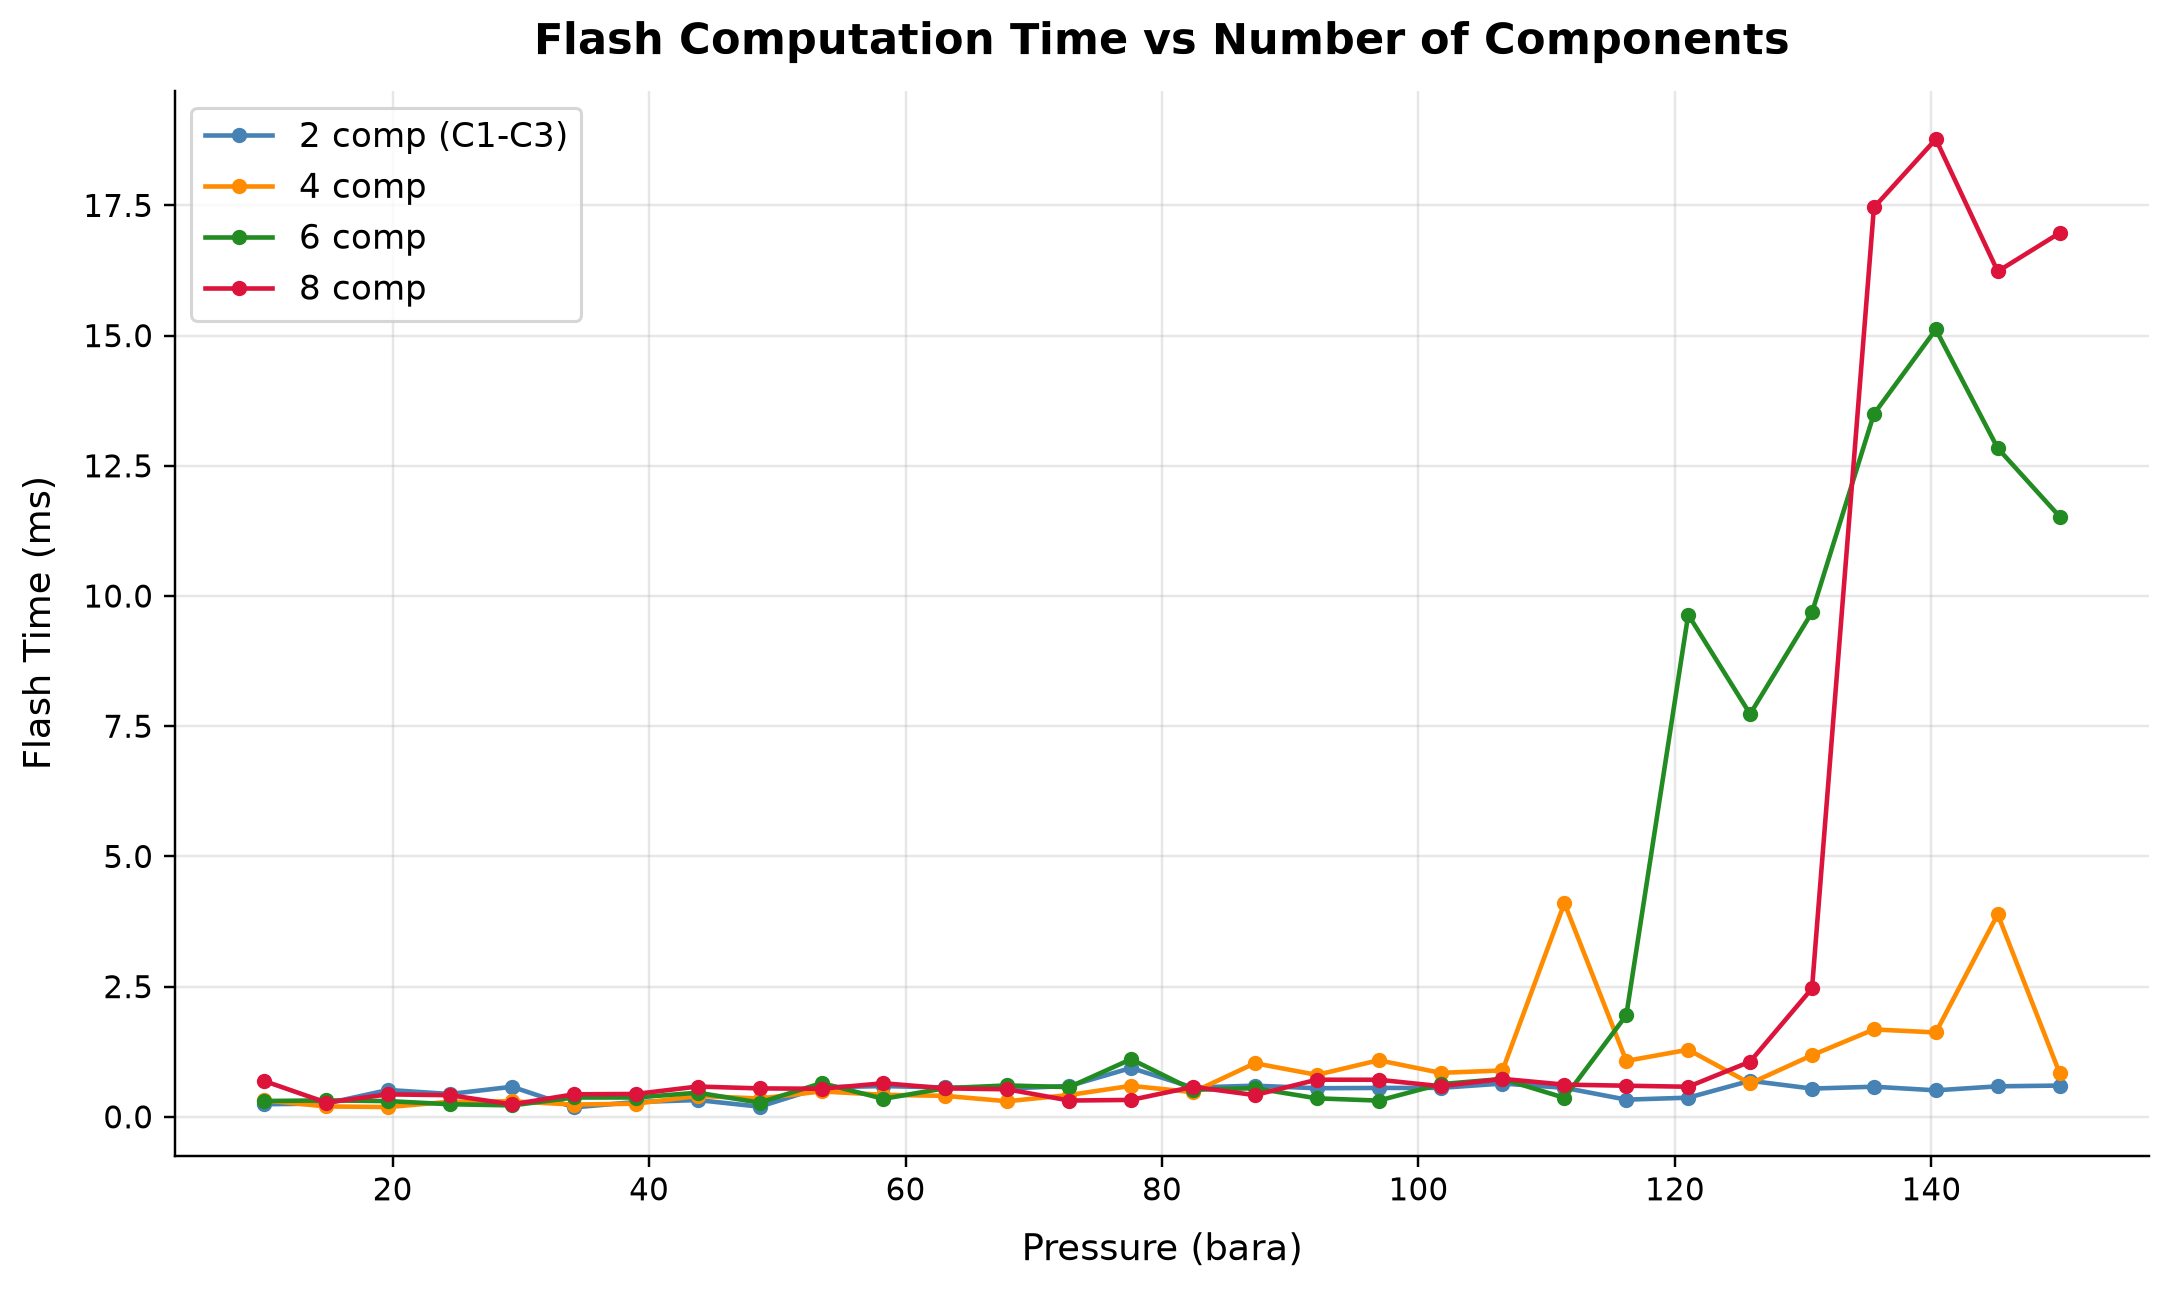

In [8]:
# Demonstrate: flash convergence sensitivity to number of components
# More components = larger Jacobian = more work per flash
component_sets = {
    "2 comp (C1-C3)": [("methane", 0.80), ("propane", 0.20)],
    "4 comp": [("methane", 0.70), ("ethane", 0.10), ("propane", 0.10), ("n-butane", 0.10)],
    "6 comp": [("methane", 0.50), ("ethane", 0.15), ("propane", 0.10),
               ("n-butane", 0.10), ("n-pentane", 0.08), ("n-hexane", 0.07)],
    "8 comp": [("nitrogen", 0.02), ("CO2", 0.03), ("methane", 0.50), ("ethane", 0.12),
               ("propane", 0.10), ("n-butane", 0.08), ("n-pentane", 0.08), ("n-hexane", 0.07)],
}

pressures_scan = np.linspace(10, 150, 30)
T_scan = 273.15 + 40.0

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']

for idx, (label, comps) in enumerate(component_sets.items()):
    times = []
    for p in pressures_scan:
        fluid = SystemSrkEos(T_scan, float(p))
        for name, frac in comps:
            fluid.addComponent(name, frac)
        fluid.setMixingRule("classic")

        ops = ThermodynamicOperations(fluid)
        t0 = time.perf_counter()
        ops.TPflash()
        elapsed = (time.perf_counter() - t0) * 1000
        times.append(elapsed)

    ax.plot(pressures_scan, times, 'o-', color=colors[idx], markersize=4,
            linewidth=1.5, label=label)

ax.set_xlabel("Pressure (bara)", fontsize=12)
ax.set_ylabel("Flash Time (ms)", fontsize=12)
ax.set_title("Flash Computation Time vs Number of Components", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch29_component_scaling.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch29_component_scaling.png")


**Executed-figure discussion.** 2 comp (C1-C3): flash time spans 0.181–0.9383 ms across the plotted cases. 4 comp: flash time spans 0.1879–4.104 ms across the plotted cases.

Adding components changes the dimension and phase behavior of the flash problem. The plotted runtime differences contain machine and phase-state effects as well as component-count effects. Use repeated, matched-state tests when selecting a fluid reduction strategy for computational speed.


### Discussion: Component Count Scaling

**Observation:** Flash calculation time increases with the number of components,
particularly in the two-phase region where the Rachford-Rice equation and
fugacity coefficient derivatives are evaluated for each component.

**Physical mechanism:** The Jacobian matrix for Newton-Raphson has dimension Nc×Nc
(number of components). More components also increase the number of successive
substitution steps needed for initial convergence.

**Engineering implication:** For production optimization with compositional fluids
(e.g., 20+ pseudo-components), flash cost dominates simulation time. Lumping
strategies (grouping similar components) provide 3-5x speedup at the expense of
some accuracy in phase behavior predictions.

**Recommendation:** Use 6-8 component lumped models for optimization loops;
validate critical cases with the full detailed composition.

## Summary

| Topic | Key Finding |
|-------|------------|
| TP Flash | Fastest in single-phase, slowest near phase boundaries |
| Initial Guess | Modest effect — NeqSim's Wilson K-value initialization is robust |
| Recycle Loops | Direct substitution converges in ~10 iterations for simple systems |
| Adjuster | Secant method efficiently finds design-spec solutions |
| Component Scaling | Flash time grows with Nc; lumping reduces cost significantly |
| SM vs EO | NeqSim uses hybrid SM (flowsheet) + EO (within columns) |

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [9]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                       Figure  Panel                        Series                   Output / unit     Minimum   Maximum  Finite points  Missing points
   ch29_flash_convergence.png      1                   T = 25.0 °C                 Flash Time (ms)      1.4414   119.384             40               0
   ch29_flash_convergence.png      1                   T = 50.0 °C                 Flash Time (ms)      0.4284   129.882             40               0
   ch29_flash_convergence.png      1                  T = 100.0 °C                 Flash Time (ms)      0.4326   19.3405             40               0
   ch29_flash_convergence.png      2                   T = 25.0 °C Gas-labelled Phase Fraction (-)    0.519109         1             40               0
   ch29_flash_convergence.png      2                   T = 50.0 °C Gas-labelled Phase Fraction (-)     0.81156         1             40               0
   ch29_flash_convergence.png      2                  T = 100.0 °C Gas-labelled Phase Fr

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [10]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 266 distinct checks, 5251 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Recycle residuals and achieved adjuster target. Timing is machine-dependent. Convergence does not establish model accuracy.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
